
 ## 1.) Se importan las librerías necesarias para el entrenamiento del modelo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 2) Se realiza el cargue del archivo de datos, realizando la lectura de los datos con pandas

In [2]:
url = "https://github.com/adiacla/bigdata/raw/master/riesgo.xlsx"
df = pd.read_excel(url)

## 3) Realizamos la inspección de los datos, para conocer la cantidad de filas y columnas, los tipos de datos etc.

In [3]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

  Customer_ID            Name     Age          SSN     Occupation  \
0  CUS_0x1000  Alistair Barrf  17.375  913-74-1218         Lawyer   
1  CUS_0x1009          Arunah  25.750  063-67-6938       Mechanic   
2  CUS_0x100b        Shirboni  18.500  238-62-0395  Media_Manager   
3  CUS_0x1011       Schneyerh  43.875  793-05-8223         Doctor   
4  CUS_0x1013        Cameront  43.750  930-49-9615       Mechanic   

   Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  \
0       30625.94            2706.161667                6.0              5.0   
1       52312.68            4250.390000                6.0              5.0   
2      113781.39            9549.782500                1.0              4.0   
3       58918.47            5208.872500                3.0              3.0   
4       98620.98            7962.415000                3.0              3.0   

   Interest_Rate  ...  Credit_Mix Outstanding_Debt  Credit_Utilization_Ratio  \
0             27  ...         

In [4]:
print(df.columns.tolist())

['Customer_ID', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


## 4) Se realiza la eliminación de columnas inncesesarias.
Teniendo en cuenta el objetivo que se busca con el entrenamiento del modelo, se validan columnas las cuales no deben entrar al modelo porque son identificadores, datos sensibles o no predictivos, como es el caso de:
- Customer_ID
- SSN
- Name

Estas columnas se eliminan puesto que no aportan valor predictivo en el contexto actual.

In [5]:
columnas_eliminar = ["Customer_ID", "SSN", "Name"]
df = df.drop(columns=columnas_eliminar)

## 5) Se realiza la separación de los datos en variables predictoras (X) y variable objetivo (y)

In [6]:
X = df.drop(columns=["Credit_Score"])
y = df["Credit_Score"]

# Verificación de la distribución
print(y.value_counts())

Credit_Score
1    6111
0    4162
2    2227
Name: count, dtype: int64


## 6) Identificación columnas
Se realiza la identificación de las columnas numéricas y categóricas para aplicar el preprocesamiento adecuado a cada tipo de dato.

In [7]:
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", columnas_numericas)
print("Categóricas:", columnas_categoricas)

Numéricas: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
Categóricas: ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


C:\Users\daelr\AppData\Local\Temp\ipykernel_72504\3259653239.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()


## 7) División de datos
Se realiza la división de los datos en conjuntos de entrenamiento y prueba utilizando la función train_test_split de sklearn, con la siguiente proporción:
- 60% para entrenamiento
- 20% para validación
- 20% para prueba


In [8]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

## 8) Preprocesamiento de los datos
Se realiza la imputación de valores faltantes, codificación de variables categóricas y normalización de las variables numéricas.

In [9]:
#Preprocesamiento para variables numéricas rellenando faltantes con la mediana y escalar con StandardScales
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#Preprocesamiento para variables categóricas rellenando faltantes con la moda y codificación con OneHotEncoder
transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

#Unificación de ambos preprocesamientos con ColumnTransformer
preprocesador = ColumnTransformer(transformers=[
    ("num", transformador_numerico, columnas_numericas),
    ("cat", transformador_categorico, columnas_categoricas)
])

## 9) Transformación de los datos
Se realiza ajuste del preprocesamiento solo con entrenamiento para luego transformar los conjuntos de validación y prueba.

In [10]:
X_train_prep = preprocesador.fit_transform(X_train)
X_val_prep = preprocesador.transform(X_val)
X_test_prep = preprocesador.transform(X_test)

print("Shape train procesado:", X_train_prep.shape)
print("Shape val procesado:", X_val_prep.shape)
print("Shape test procesado:", X_test_prep.shape)

Shape train procesado: (7500, 4070)
Shape val procesado: (2500, 4070)
Shape test procesado: (2500, 4070)


## 10) Reducción de dimensionalidad con PCA
Puesto que el preprocesamiento con OneHotEncoder puede generar un gran número de características, se aplica PCA para reducir la dimensionalidad y evitar el sobreajuste.

In [11]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_prep)
X_val_pca = pca.transform(X_val_prep)
X_test_pca = pca.transform(X_test_prep)

print("Shape train con PCA:", X_train_pca.shape)
print("Shape val con PCA:", X_val_pca.shape)
print("Shape test con PCA:", X_test_pca.shape)

print("Varianza explicada acumulada:", np.sum(pca.explained_variance_ratio_))

Shape train con PCA: (7500, 36)
Shape val con PCA: (2500, 36)
Shape test con PCA: (2500, 36)
Varianza explicada acumulada: 0.9519371541186995


In [12]:
#Verificar el número de componentes principales seleccionados
print("Número de componentes principales:", pca.n_components_)

Número de componentes principales: 36


## 11) Contrucción del modelo de red neuronal
Se realiza la construcción de un modelo secuencial con varias capas ocultas, utilizando la función de activación ReLU y una capa de salida con activación softmax para clasificación multiclase.



In [13]:
modelo = Sequential([
    Input(shape=(X_train_pca.shape[1],)),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(3, activation="softmax")
])

## 12) Compilación del modelo
Se compila el modelo utilizando el optimizador Adam, la función de pérdida categorical_crossentropy y la métrica de accuracy para evaluar el rendimiento durante el entrenamiento.

In [14]:
modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,171 (59.26 KB)

 Trainable params: 15,171 (59.26 KB)

 Non-trainable params: 0 (0.00 B)

## 13) Early Stopping
Se implementa Early Stopping para evitar el sobreajuste, deteniendo el entrenamiento si la pérdida de validación no mejora durante 10 épocas consecutivas.

In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=1e-4,
    restore_best_weights=True
)

## 14) Entrenamiento del modelo
Se entrena el modelo utilizando el método fit, pasando los datos de entrenamiento y validación, con un número máximo de épocas de 100 y un tamaño de lote de 32.

In [16]:
historial = modelo.fit(
    X_train_pca, y_train,
    validation_data=(X_val_pca, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6695 - loss: 0.7452 - val_accuracy: 0.7140 - val_loss: 0.6531
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7173 - loss: 0.6477 - val_accuracy: 0.7292 - val_loss: 0.6243
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7297 - loss: 0.6233 - val_accuracy: 0.7352 - val_loss: 0.6192
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7345 - loss: 0.6183 - val_accuracy: 0.7304 - val_loss: 0.6151
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7400 - loss: 0.6063 - val_accuracy: 0.7452 - val_loss: 0.6064
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7477 - loss: 0.5989 - val_accuracy: 0.7392 - val_loss: 0.6017
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7479 - loss: 0.5928 - val_accuracy: 0.7396 - val_loss: 0.6022
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7547 - loss: 0.5873 - val_accu

## 15) Graficar la evolución de la pérdida y precisión durante el entrenamiento
Se visualiza la evolución de la pérdida y precisión tanto para el conjunto de entrenamiento como para el de validación a lo largo de las épocas para evaluar el comportamiento del modelo durante el entrenamiento.

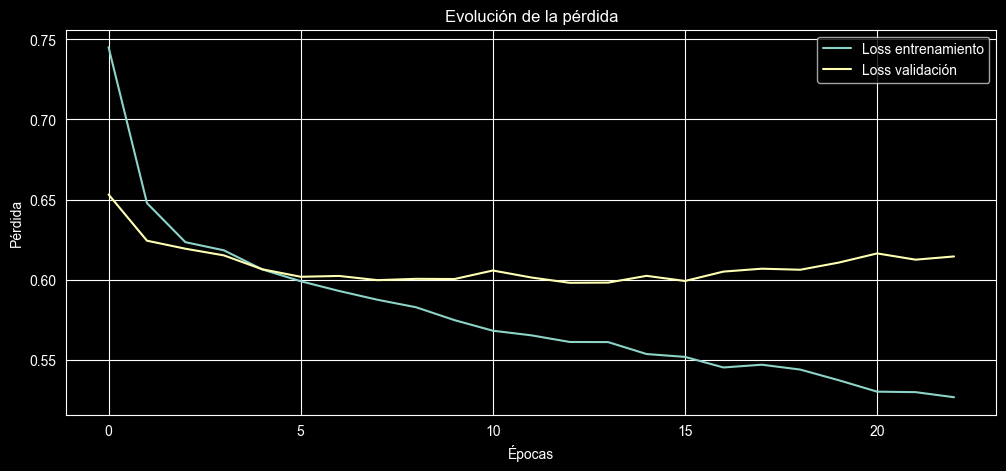

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(historial.history["loss"], label="Loss entrenamiento")
plt.plot(historial.history["val_loss"], label="Loss validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida")
plt.legend()
plt.show()

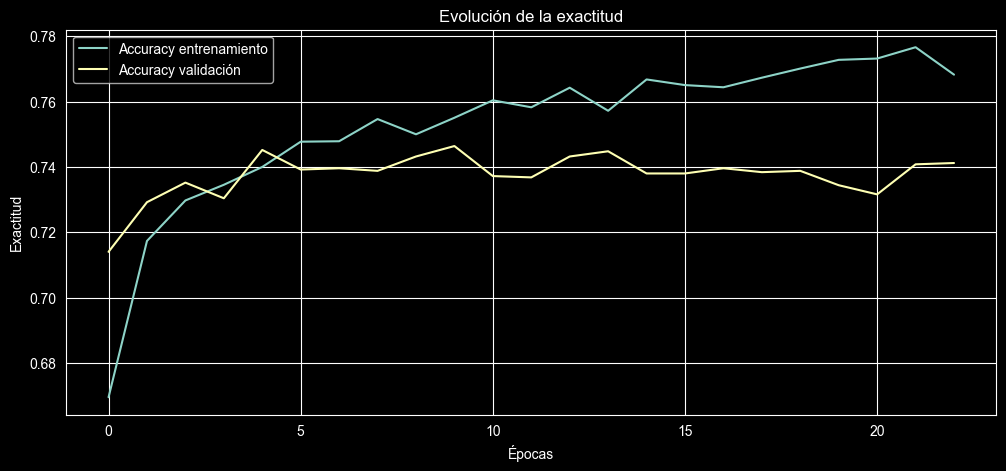

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(historial.history["accuracy"], label="Accuracy entrenamiento")
plt.plot(historial.history["val_accuracy"], label="Accuracy validación")
plt.xlabel("Épocas")
plt.ylabel("Exactitud")
plt.title("Evolución de la exactitud")
plt.legend()
plt.show()

## 16) Evaluación final del modelo
Se evalúa el modelo en el conjunto de prueba para obtener la pérdida y precisión final, además de generar un reporte de clasificación y una matriz de confusión para analizar el rendimiento del modelo en cada clase.

In [19]:
loss_test, acc_test = modelo.evaluate(X_test_pca, y_test, verbose=0)

print("Loss en test:", loss_test)
print("Accuracy en test:", acc_test)

Loss en test: 0.6094317436218262
Accuracy en test: 0.746399998664856


## 17) Predicciones
Se generan predicciones utilizando el modelo entrenado sobre el conjunto de prueba, para luego comparar las etiquetas predichas con las reales y generar un reporte de clasificación detallado.

In [20]:
y_prob = modelo.predict(X_test_pca)
y_pred = np.argmax(y_prob, axis=1)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


## 18) Metricas de clasificación
Se genera un reporte de clasificación utilizando la función classification_report de sklearn, que incluye métricas como precisión, recall y F1-score para cada clase, además de la matriz de confusión para visualizar el rendimiento del modelo en cada clase.

In [21]:
print("Accuracy final:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Accuracy final: 0.7464

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.68      0.74       833
           1       0.80      0.77      0.78      1222
           2       0.58      0.80      0.67       445

    accuracy                           0.75      2500
   macro avg       0.73      0.75      0.73      2500
weighted avg       0.76      0.75      0.75      2500

Matriz de confusión:
[[569 179  85]
 [111 940 171]
 [ 28  60 357]]


## 19) Probar modelo con nuevos datos
Se generan nuevos datos de prueba para evaluar el modelo con ejemplos no vistos durante el entrenamiento, y se realizan predicciones para estos nuevos datos para evaluar la capacidad del modelo para generalizar a nuevos casos.

In [22]:
nuevo_cliente = pd.DataFrame([{
    "Age": 35,
    "Occupation": "Engineer",
    "Annual_Income": 85000,
    "Monthly_Inhand_Salary": 6500,
    "Num_Bank_Accounts": 4,
    "Num_Credit_Card": 3,
    "Interest_Rate": 12,
    "Num_of_Loan": 2,
    "Type_of_Loan": "Personal Loan, Home Loan",
    "Delay_from_due_date": 5,
    "Num_of_Delayed_Payment": 2,
    "Changed_Credit_Limit": 1,
    "Num_Credit_Inquiries": 3,
    "Credit_Mix": "Good",
    "Outstanding_Debt": 1200,
    "Credit_Utilization_Ratio": 28.5,
    "Credit_History_Age": 220,
    "Payment_of_Min_Amount": "Yes",
    "Total_EMI_per_month": 350,
    "Amount_invested_monthly": 400,
    "Payment_Behaviour": "High_spent_Small_value_payments",
    "Monthly_Balance": 1500
}])

nuevo_cliente_prep = preprocesador.transform(nuevo_cliente)
nuevo_cliente_pca = pca.transform(nuevo_cliente_prep)

pred_prob = modelo.predict(nuevo_cliente_pca)
pred_clase = np.argmax(pred_prob, axis=1)

print("Clase predicha:", pred_clase[0])
print("Probabilidades:", pred_prob[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Clase predicha: 1
Probabilidades: [0.01400683 0.68833965 0.29765356]
